# Employment Shortages AUS
Notebook for analyzing Australian employment shortages data.

In [1]:
from pathlib import Path

import re

import pandas as pd

from IPython.display import display



# Locate EmploymentShortages folder whether notebook runs from workspace root or docs/

candidate_dirs = [

    Path.cwd() / "EmploymentShortages",

    Path.cwd().parent / "EmploymentShortages",

    Path("EmploymentShortages"),

    Path("../EmploymentShortages"),

]



shortages_dir = next((path.resolve() for path in candidate_dirs if path.exists()), None)

if shortages_dir is None:

    raise FileNotFoundError("Could not find the 'EmploymentShortages' folder.")



files = sorted(

    [

        path for path in shortages_dir.iterdir()

        if path.suffix.lower() in {".csv", ".xlsx", ".xls"}

    ],

    key=lambda p: p.name.lower(),

)



if not files:

    raise FileNotFoundError(f"No CSV/XLSX files found in: {shortages_dir}")





def read_table(file_path: Path) -> pd.DataFrame:

    if file_path.suffix.lower() == ".csv":

        return pd.read_csv(file_path)

    return pd.read_excel(file_path)





employment_shortages_tables = {}

employment_shortages_parts = []



for file_path in files:

    df = read_table(file_path)

    table_name = file_path.stem.replace(" ", "_").replace("-", "_")

    employment_shortages_tables[table_name] = df



    year_match = re.search(r"(20\d{2})", file_path.stem)

    year_value = int(year_match.group(1)) if year_match else pd.NA



    df_with_meta = df.copy()

    df_with_meta["year"] = year_value

    df_with_meta["source_file"] = file_path.name

    employment_shortages_parts.append(df_with_meta)



employment_shortages_df = pd.concat(employment_shortages_parts, ignore_index=True)



print(f"Loaded {len(files)} files from: {shortages_dir}")

print("Files:")

for path in files:

    print(f"- {path.name}")



print(f"\nCombined rows: {len(employment_shortages_df)}, Columns: {len(employment_shortages_df.columns)}")

display(employment_shortages_df.head(20))


Loaded 5 files from: C:\Users\neddp\ECC3479-Project-JRGS\EmploymentShortages
Files:
- OSL 2021 (ANZSCO 6).csv
- OSL 2022 (ANZSCO 6).csv
- OSL 2023 (ANZSCO 6).csv
- OSL 2024 (ANZSCO 6).csv
- OSL 2025 (ANZSCO 6).csv

Combined rows: 4486, Columns: 14


,Code,Occupation,National Shortage Rating,New South Wales Shortage Rating,Victoria Shortage Rating,Queensland Shortage Rating,South Australia Shortage Rating,Western Australia Shortage Rating,Tasmania Shortage Rating,Northern Territory Shortage Rating,Australian Capital Territory Shortage Rating,Skill Level,year,source_file
0,111111,Chief Executive or Managing Director,No shortage,No shortage,No shortage,No shortage,No shortage,Regional shortage,No shortage,No shortage,No shortage,1,2021,OSL 2021 (ANZSCO 6).csv
1,111211,Corporate General Manager,No shortage,Shortage,No shortage,No shortage,No shortage,No shortage,No shortage,No shortage,No shortage,1,2021,OSL 2021 (ANZSCO 6).csv
2,121111,Aquaculture Farmer,No shortage,Shortage,No shortage,No shortage,Shortage,No shortage,Shortage,Shortage,No shortage,1,2021,OSL 2021 (ANZSCO 6).csv
3,121311,Apiarist,No shortage,Shortage,No shortage,No shortage,No shortage,No shortage,No shortage,Shortage,No shortage,1,2021,OSL 2021 (ANZSCO 6).csv
4,121312,Beef Cattle Farmer,No shortage,No shortage,No shortage,No shortage,No shortage,No shortage,No shortage,No shortage,No shortage,1,2021,OSL 2021 (ANZSCO 6).csv
5,121313,Dairy Cattle Farmer,No shortage,No shortage,No shortage,No shortage,Shortage,No shortage,Shortage,Shortage,No shortage,1,2021,OSL 2021 (ANZSCO 6).csv
6,121314,Deer Farmer,No shortage,No shortage,No shortage,No shortage,No shortage,No shortage,No shortage,No shortage,No shortage,1,2021,OSL 2021 (ANZSCO 6).csv
7,121315,Goat Farmer,No shortage,No shortage,No shortage,No shortage,No shortage,No shortage,No shortage,No shortage,No shortage,1,2021,OSL 2021 (ANZSCO 6).csv
8,121316,Horse Breeder,No shortage,No shortage,No shortage,No shortage,No shortage,No shortage,No shortage,No shortage,No shortage,1,2021,OSL 2021 (ANZSCO 6).csv
9,121318,Pig Farmer,Shortage,Shortage,Shortage,Shortage,Shortage,Shortage,Shortage,Shortage,Shortage,1,2021,OSL 2021 (ANZSCO 6).csv


In [2]:
# Cell 3 — Profile employment shortages data
import re

print(f"Rows: {len(employment_shortages_df):,}")
print(f"Columns: {len(employment_shortages_df.columns)}")
print("\nColumn names:")
for col in employment_shortages_df.columns:
    print(f"- {col}")

# Identify likely metric and grouping columns for plotting
metric_candidates = [
    c for c in employment_shortages_df.columns
    if re.search(r"short|rate|pct|percent|score|index", c, flags=re.IGNORECASE)
]
label_candidates = [
    c for c in employment_shortages_df.columns
    if re.search(r"anzsco|occupation|title|name|group", c, flags=re.IGNORECASE)
]

print("\nLikely metric columns:", metric_candidates if metric_candidates else "None detected")
print("Likely occupation label columns:", label_candidates if label_candidates else "None detected")

employment_shortages_df.head(5)

Rows: 4,486
Columns: 14

Column names:
- Code
- Occupation
- National Shortage Rating
- New South Wales Shortage Rating
- Victoria Shortage Rating
- Queensland Shortage Rating
- South Australia Shortage Rating
- Western Australia Shortage Rating
- Tasmania Shortage Rating
- Northern Territory Shortage Rating
- Australian Capital Territory Shortage Rating
- Skill Level
- year
- source_file

Likely metric columns: ['National Shortage Rating', 'New South Wales Shortage Rating', 'Victoria Shortage Rating', 'Queensland Shortage Rating', 'South Australia Shortage Rating', 'Western Australia Shortage Rating', 'Tasmania Shortage Rating', 'Northern Territory Shortage Rating', 'Australian Capital Territory Shortage Rating']
Likely occupation label columns: ['Occupation']


,Code,Occupation,National Shortage Rating,New South Wales Shortage Rating,Victoria Shortage Rating,Queensland Shortage Rating,South Australia Shortage Rating,Western Australia Shortage Rating,Tasmania Shortage Rating,Northern Territory Shortage Rating,Australian Capital Territory Shortage Rating,Skill Level,year,source_file
0,111111,Chief Executive or Managing Director,No shortage,No shortage,No shortage,No shortage,No shortage,Regional shortage,No shortage,No shortage,No shortage,1,2021,OSL 2021 (ANZSCO 6).csv
1,111211,Corporate General Manager,No shortage,Shortage,No shortage,No shortage,No shortage,No shortage,No shortage,No shortage,No shortage,1,2021,OSL 2021 (ANZSCO 6).csv
2,121111,Aquaculture Farmer,No shortage,Shortage,No shortage,No shortage,Shortage,No shortage,Shortage,Shortage,No shortage,1,2021,OSL 2021 (ANZSCO 6).csv
3,121311,Apiarist,No shortage,Shortage,No shortage,No shortage,No shortage,No shortage,No shortage,Shortage,No shortage,1,2021,OSL 2021 (ANZSCO 6).csv
4,121312,Beef Cattle Farmer,No shortage,No shortage,No shortage,No shortage,No shortage,No shortage,No shortage,No shortage,No shortage,1,2021,OSL 2021 (ANZSCO 6).csv


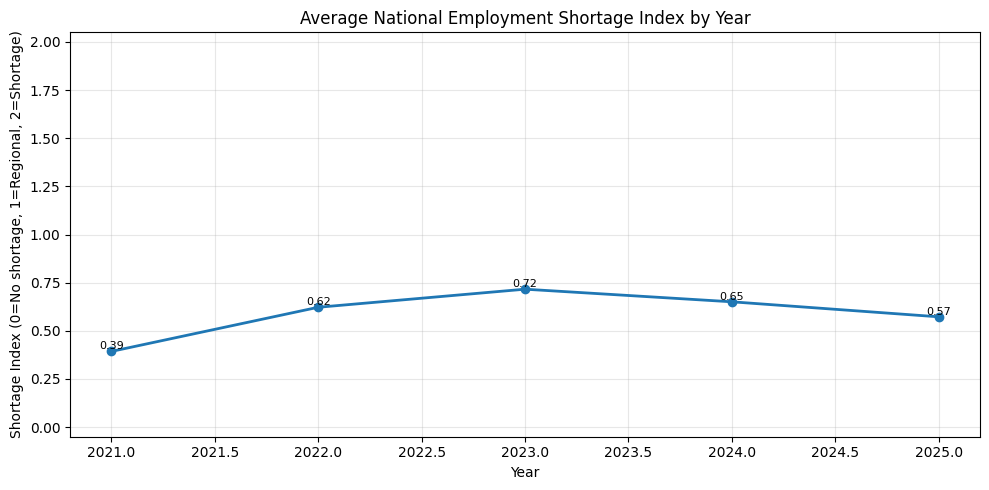

,year,shortage_index
0,2021,0.392944
1,2022,0.622271
2,2023,0.716157
3,2024,0.650655
4,2025,0.572678


In [3]:
# Cell 4 — Yearly employment shortage trend (overall)
import matplotlib.pyplot as plt

plot_df = employment_shortages_df.copy()

# Use national rating where available, otherwise fall back to first shortage-rating column
preferred_metric_order = ["National Shortage Rating"]
metric_col = next((c for c in preferred_metric_order if c in plot_df.columns), None)

if metric_col is None:
    auto_candidates = [c for c in plot_df.columns if "shortage rating" in c.lower()]
    metric_col = auto_candidates[0] if auto_candidates else None

if metric_col is None:
    raise ValueError("No shortage rating column found. Run Cell 3 to inspect available columns.")

# Convert categorical ratings to numeric shortage index
rating_to_score = {
    "shortage": 2,
    "regional shortage": 1,
    "no shortage": 0,
}

rating_series = plot_df[metric_col].astype(str).str.strip().str.lower()
plot_df["shortage_index"] = rating_series.map(rating_to_score)

yearly_trend = (
    plot_df.dropna(subset=["year", "shortage_index"])
    .groupby("year", as_index=False)["shortage_index"]
    .mean()
    .sort_values("year")
)

if yearly_trend.empty:
    raise ValueError(f"No usable values found in shortage rating column: {metric_col}")

plt.figure(figsize=(10, 5))
plt.plot(yearly_trend["year"], yearly_trend["shortage_index"], marker="o", linewidth=2)
plt.title("Average National Employment Shortage Index by Year")
plt.xlabel("Year")
plt.ylabel("Shortage Index (0=No shortage, 1=Regional, 2=Shortage)")
plt.ylim(-0.05, 2.05)
plt.grid(alpha=0.3)

for x, y in zip(yearly_trend["year"], yearly_trend["shortage_index"]):
    plt.text(x, y, f"{y:.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

yearly_trend

In [4]:
# Cell 5 — Inspect 2025 industry workbook structure
from pathlib import Path
import pandas as pd

candidate_dirs = [Path.cwd(), Path.cwd().parent]
industry_file = None
for base in candidate_dirs:
    candidate = base / "EmploymentOutcomes" / "industry_data_-_november_2025_revised (1).xlsx"
    if candidate.exists():
        industry_file = candidate
        break

if industry_file is None:
    raise FileNotFoundError("Could not find industry_data_-_november_2025_revised (1).xlsx in expected locations")

print(f"Using file: {industry_file}")
xls = pd.ExcelFile(industry_file)
print("\nSheets:")
for i, sheet in enumerate(xls.sheet_names, start=1):
    print(f"{i}. {sheet}")

sheet_preview = {}
for sheet in xls.sheet_names:
    preview = pd.read_excel(industry_file, sheet_name=sheet, nrows=8)
    sheet_preview[sheet] = preview

print("\nPreview of first sheet:")
sheet_preview[xls.sheet_names[0]]

Using file: C:\Users\neddp\ECC3479-Project-JRGS\EmploymentOutcomes\industry_data_-_november_2025_revised (1).xlsx



Sheets:
1. Contents
2. Table_1
3. Table_2
4. Table_3
5. Table_4



Preview of first sheet:


,Unnamed: 0,Unnamed: 1
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,Industry data - November 2025,NaN
4,NaN,NaN
5,NaN,NaN
6,NaN,Contents


In [5]:
# Cell 6 — Profile data tables for industry/employment columns
def preview_sheet(sheet_name, rows=12):
    raw = pd.read_excel(industry_file, sheet_name=sheet_name, header=None, nrows=rows)
    print(f"\n===== {sheet_name} (raw preview) =====")
    display(raw)

for sheet in ["Table_1", "Table_2", "Table_3", "Table_4"]:
    preview_sheet(sheet, rows=12)


===== Table_1 (raw preview) =====


,0,1,2,3,4,5,6
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,Back to Contents
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Table 1 - Overview,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Industry,Employed,Female Share (%),Part-time Share (%),Median Weekly Earnings,Workforce Share (%),Median Age
7,"Agriculture, Forestry and Fishing",285500,32,28,1358,1.9,51
8,Mining,297500,20,5,2832,2,42
9,Manufacturing,869100,30,17,1654,5.9,43



===== Table_2 (raw preview) =====


,0,1,2,3,4,5,6,7,8,9,...,76,77,78,79,80,81,82,83,84,85
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,Back to Contents,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Table 2 - Employment - 20 year series,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Industry,Nov-05,Feb-06,May-06,Aug-06,Nov-06,Feb-07,May-07,Aug-07,Nov-07,...,Aug-24,Nov-24,Feb-25,May-25,Aug-25,Nov-25,1 Year Growth,1 Year Growth %,20 Year Growth,20 Year Growth %
7,"Agriculture, Forestry and Fishing",349400,348100,347100,346400,345900,345700,345600,345700,345900,...,301700,299100,296100,292800,289300,285500,-13500,-4.5,-63800,-18.3
8,Mining,119300,122600,125900,129100,132300,135600,139000,142500,146100,...,305100,304200,302900,301300,299500,297500,-6700,-2.2,178200,149.3
9,Manufacturing,1016900,1014100,1012500,1012600,1015200,1021000,1029100,1037600,1045300,...,892800,884600,877200,871300,868400,869100,-15500,-1.7,-147700,-14.5



===== Table_3 (raw preview) =====


,0,1,2,3
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,Back to Contents
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,Table 3 - Employment by sector,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN
6,Industry,Sector,Employed,NaN
7,"Agriculture, Forestry and Fishing","Sheep, Beef Cattle and Grain Farming",118300,NaN
8,"Agriculture, Forestry and Fishing",Fruit and Tree Nut Growing,25200,NaN
9,"Agriculture, Forestry and Fishing",Agriculture and Fishing Support Services,23300,NaN



===== Table_4 (raw preview) =====


,0,1,2,3,4
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,Back to Contents
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,Table 4 - Top employing occupations,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN
6,Industry,ANZSCO Code,Occupation (ranked),NaN,NaN
7,"Agriculture, Forestry and Fishing",1213,Livestock Farmers,NaN,NaN
8,"Agriculture, Forestry and Fishing",1212,Crop Farmers,NaN,NaN
9,"Agriculture, Forestry and Fishing",1214,Mixed Crop and Livestock Farmers,NaN,NaN


In [6]:
# Cell 7 — Employment figures table for all industries (2025)
raw_table1 = pd.read_excel(industry_file, sheet_name="Table_1", header=None)

# Header starts at row index 6 based on workbook structure
headers = raw_table1.iloc[6].tolist()
industry_table = raw_table1.iloc[7:].copy()
industry_table.columns = headers

employment_by_industry_2025 = (
    industry_table[["Industry", "Employed"]]
    .dropna(subset=["Industry", "Employed"])
    .copy()
)

employment_by_industry_2025["Industry"] = employment_by_industry_2025["Industry"].astype(str).str.strip()
employment_by_industry_2025["Employed"] = pd.to_numeric(
    employment_by_industry_2025["Employed"], errors="coerce"
)
employment_by_industry_2025 = employment_by_industry_2025.dropna(subset=["Employed"])

# Remove non-industry rows if present
employment_by_industry_2025 = employment_by_industry_2025[
    ~employment_by_industry_2025["Industry"].str.lower().isin(["all industries", "total"])
].reset_index(drop=True)

employment_by_industry_2025["Employed"] = employment_by_industry_2025["Employed"].astype(int)

print(f"Industries included: {len(employment_by_industry_2025)}")
employment_by_industry_2025

Industries included: 19


,Industry,Employed
0,"Agriculture, Forestry and Fishing",285500
1,Mining,297500
2,Manufacturing,869100
3,"Electricity, Gas, Water and Waste Services",217200
4,Construction,1360000
5,Wholesale Trade,338300
6,Retail Trade,1343700
7,Accommodation and Food Services,981100
8,"Transport, Postal and Warehousing",739400
9,Information Media and Telecommunications,184200


In [7]:
# Cell 8 — Employment table (industry x time) for full available period (~20 years)
import re

raw_table2 = pd.read_excel(industry_file, sheet_name="Table_2", header=None)

# Header row is the row containing "Industry"
header_row_idx = raw_table2.index[
    raw_table2.iloc[:, 0].astype(str).str.strip().str.lower().eq("industry")
]
if len(header_row_idx) == 0:
    raise ValueError("Could not find header row with 'Industry' in Table_2")
header_row_idx = int(header_row_idx[0])

headers = raw_table2.iloc[header_row_idx].tolist()
employment_by_industry_20y = raw_table2.iloc[header_row_idx + 1 :].copy()
employment_by_industry_20y.columns = headers

# Keep only columns with valid header names
employment_by_industry_20y = employment_by_industry_20y.loc[:, ~pd.isna(employment_by_industry_20y.columns)]
employment_by_industry_20y.columns = [str(c).strip() for c in employment_by_industry_20y.columns]

# Keep industry rows only
employment_by_industry_20y = employment_by_industry_20y.dropna(subset=["Industry"]).copy()
employment_by_industry_20y["Industry"] = employment_by_industry_20y["Industry"].astype(str).str.strip()
employment_by_industry_20y = employment_by_industry_20y[
    ~employment_by_industry_20y["Industry"].str.lower().isin(["all industries", "total"])
]

# Keep only date-like time columns in MMM-YY format
month_pattern = re.compile(r"^(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)-\d{2}$", re.IGNORECASE)
time_cols = [c for c in employment_by_industry_20y.columns if c != "Industry" and month_pattern.match(c)]

# Convert time columns to whole-number employment values
for col in time_cols:
    employment_by_industry_20y[col] = pd.to_numeric(
        employment_by_industry_20y[col].astype(str).str.replace(",", "", regex=False),
        errors="coerce",
    )
    employment_by_industry_20y[col] = employment_by_industry_20y[col].round().astype("Int64")

employment_by_industry_20y = employment_by_industry_20y[["Industry"] + time_cols].reset_index(drop=True)

print(f"Industries: {employment_by_industry_20y.shape[0]}")
print(f"Time periods: {len(time_cols)}")
if time_cols:
    print(f"Range: {time_cols[0]} to {time_cols[-1]}")

employment_by_industry_20y

Industries: 19
Time periods: 81
Range: Nov-05 to Nov-25


,Industry,Nov-05,Feb-06,May-06,Aug-06,Nov-06,Feb-07,May-07,Aug-07,Nov-07,...,Aug-23,Nov-23,Feb-24,May-24,Aug-24,Nov-24,Feb-25,May-25,Aug-25,Nov-25
0,"Agriculture, Forestry and Fishing",349400,348100,347100,346400,345900,345700,345600,345700,345900,...,308500,307200,305700,303900,301700,299100,296100,292800,289300,285500
1,Mining,119300,122600,125900,129100,132300,135600,139000,142500,146100,...,305900,306300,306200,305800,305100,304200,302900,301300,299500,297500
2,Manufacturing,1016900,1014100,1012500,1012600,1015200,1021000,1029100,1037600,1045300,...,904800,909400,907500,901100,892800,884600,877200,871300,868400,869100
3,"Electricity, Gas, Water and Waste Services",100800,102500,104200,106000,107900,109800,111800,113900,116100,...,177700,181400,185300,189500,193800,198300,202900,207500,212300,217200
4,Construction,858900,872300,886000,900400,914700,925500,932900,940600,951800,...,1321000,1328600,1334100,1338800,1342500,1348100,1351400,1351300,1353700,1360000
5,Wholesale Trade,380700,382500,384500,386400,388400,390300,392100,393900,395700,...,367400,366200,364400,361900,358900,355300,351400,347100,342800,338300
6,Retail Trade,1163100,1162900,1163700,1166900,1173100,1181400,1191800,1204100,1214900,...,1330100,1327700,1326600,1326600,1330700,1335300,1337800,1339800,1341500,1343700
7,Accommodation and Food Services,673300,668900,669000,673800,680800,688600,694800,698900,700700,...,925200,923100,927200,937000,947400,954400,958800,964000,971800,981100
8,"Transport, Postal and Warehousing",496500,498200,501000,504600,510000,518200,527800,536900,545600,...,726800,731200,733000,734100,735600,738500,740200,741400,740500,739400
9,Information Media and Telecommunications,232800,233200,233400,233400,233200,232800,232200,231400,230500,...,188300,187800,187300,186800,186400,185900,185500,185000,184600,184200


In [8]:
# Cell 9 — Export 20-year industry employment table
from pathlib import Path

export_base_dirs = [Path.cwd() / "data" / "clean", Path.cwd().parent / "data" / "clean"]
export_dir = next((d for d in export_base_dirs if d.exists()), export_base_dirs[0])
export_dir.mkdir(parents=True, exist_ok=True)

csv_path = export_dir / "employment_by_industry_20y.csv"
xlsx_path = export_dir / "employment_by_industry_20y.xlsx"

employment_by_industry_20y.to_csv(csv_path, index=False)
employment_by_industry_20y.to_excel(xlsx_path, index=False)

print(f"Exported CSV: {csv_path}")
print(f"Exported Excel: {xlsx_path}")

Exported CSV: C:\Users\neddp\ECC3479-Project-JRGS\data\clean\employment_by_industry_20y.csv
Exported Excel: C:\Users\neddp\ECC3479-Project-JRGS\data\clean\employment_by_industry_20y.xlsx


In [9]:
# Cell 10 — Export transposed industry employment table (time x industries)
employment_by_industry_20y_transposed = employment_by_industry_20y.set_index("Industry").T
employment_by_industry_20y_transposed.index.name = "Period"
employment_by_industry_20y_transposed.columns.name = None
employment_by_industry_20y_transposed = employment_by_industry_20y_transposed.reset_index()

transposed_csv_path = export_dir / "employment_by_industry_20y_transposed.csv"
transposed_xlsx_path = export_dir / "employment_by_industry_20y_transposed.xlsx"

employment_by_industry_20y_transposed.to_csv(transposed_csv_path, index=False)
employment_by_industry_20y_transposed.to_excel(transposed_xlsx_path, index=False)

print(f"Exported transposed CSV: {transposed_csv_path}")
print(f"Exported transposed Excel: {transposed_xlsx_path}")
employment_by_industry_20y_transposed.head()

Exported transposed CSV: C:\Users\neddp\ECC3479-Project-JRGS\data\clean\employment_by_industry_20y_transposed.csv


Exported transposed Excel: C:\Users\neddp\ECC3479-Project-JRGS\data\clean\employment_by_industry_20y_transposed.xlsx


,Period,"Agriculture, Forestry and Fishing",Mining,Manufacturing,"Electricity, Gas, Water and Waste Services",Construction,Wholesale Trade,Retail Trade,Accommodation and Food Services,"Transport, Postal and Warehousing",Information Media and Telecommunications,Financial and Insurance Services,"Rental, Hiring and Real Estate Services","Professional, Scientific and Technical Services",Administrative and Support Services,Public Administration and Safety,Education and Training,Health Care and Social Assistance,Arts and Recreation Services,Other Services
0,Nov-05,349400,119300,1016900,100800,858900,380700,1163100,673300,496500,232800,374000,185500,701700,346900,612200,730400,1013900,172000,407000
1,Feb-06,348100,122600,1014100,102500,872300,382500,1162900,668900,498200,233200,378700,187400,713100,347200,616000,734500,1028200,174400,409100
2,May-06,347100,125900,1012500,104200,886000,384500,1163700,669000,501000,233400,384400,189100,722700,347400,621700,737200,1040500,176800,411600
3,Aug-06,346400,129100,1012600,106000,900400,386400,1166900,673800,504600,233400,390700,190700,730300,347600,627500,739800,1049200,179100,413800
4,Nov-06,345900,132300,1015200,107900,914700,388400,1173100,680800,510000,233200,397400,192000,735500,347800,632400,744300,1055900,181300,417600


In [10]:
# Cell 11 — Apply AUS CategoryKey mapping to industry employment table and export +keys files
category_key_to_name = {
    1: "Natural & Physical Science",
    2: "Information Technology",
    3: "Engineering & Related Tech",
    4: "Architecture & Building",
    5: "Environment & Related",
    6: "Health",
    7: "Education",
    8: "Management & Commerce",
    9: "Society & Culture",
    10: "Creative Arts",
    11: "Others",
    99: "Total",
}

industry_to_category_key = {
    "Agriculture, Forestry and Fishing": 5,
    "Mining": 3,
    "Manufacturing": 3,
    "Electricity, Gas, Water and Waste Services": 3,
    "Construction": 4,
    "Wholesale Trade": 8,
    "Retail Trade": 8,
    "Accommodation and Food Services": 8,
    "Transport, Postal and Warehousing": 8,
    "Information Media and Telecommunications": 2,
    "Financial and Insurance Services": 8,
    "Rental, Hiring and Real Estate Services": 8,
    "Professional, Scientific and Technical Services": 1,
    "Administrative and Support Services": 8,
    "Public Administration and Safety": 9,
    "Education and Training": 7,
    "Health Care and Social Assistance": 6,
    "Arts and Recreation Services": 10,
    "Other Services": 11,
}

employment_by_industry_20y_with_keys = employment_by_industry_20y.copy()
employment_by_industry_20y_with_keys["CategoryKey"] = (
    employment_by_industry_20y_with_keys["Industry"].map(industry_to_category_key).astype("Int64")
)
employment_by_industry_20y_with_keys["Category"] = (
    employment_by_industry_20y_with_keys["CategoryKey"].map(category_key_to_name)
)

unmapped = employment_by_industry_20y_with_keys[
    employment_by_industry_20y_with_keys["CategoryKey"].isna()
]["Industry"].tolist()
if unmapped:
    print("Unmapped industries:", unmapped)

ordered_cols = ["Industry", "Category", "CategoryKey"] + [
    c for c in employment_by_industry_20y_with_keys.columns if c not in {"Industry", "Category", "CategoryKey"}
]
employment_by_industry_20y_with_keys = employment_by_industry_20y_with_keys[ordered_cols]

with_keys_csv_path = export_dir / "employment_by_industry_20y+keys.csv"
with_keys_xlsx_path = export_dir / "employment_by_industry_20y+keys.xlsx"

employment_by_industry_20y_with_keys.to_csv(with_keys_csv_path, index=False)
employment_by_industry_20y_with_keys.to_excel(with_keys_xlsx_path, index=False)

print(f"Exported CSV: {with_keys_csv_path}")
print(f"Exported Excel: {with_keys_xlsx_path}")
print(f"Rows: {employment_by_industry_20y_with_keys.shape[0]}, Columns: {employment_by_industry_20y_with_keys.shape[1]}")
employment_by_industry_20y_with_keys.head()

Exported CSV: C:\Users\neddp\ECC3479-Project-JRGS\data\clean\employment_by_industry_20y+keys.csv
Exported Excel: C:\Users\neddp\ECC3479-Project-JRGS\data\clean\employment_by_industry_20y+keys.xlsx
Rows: 19, Columns: 84


,Industry,Category,CategoryKey,Nov-05,Feb-06,May-06,Aug-06,Nov-06,Feb-07,May-07,...,Aug-23,Nov-23,Feb-24,May-24,Aug-24,Nov-24,Feb-25,May-25,Aug-25,Nov-25
0,"Agriculture, Forestry and Fishing",Environment & Related,5,349400,348100,347100,346400,345900,345700,345600,...,308500,307200,305700,303900,301700,299100,296100,292800,289300,285500
1,Mining,Engineering & Related Tech,3,119300,122600,125900,129100,132300,135600,139000,...,305900,306300,306200,305800,305100,304200,302900,301300,299500,297500
2,Manufacturing,Engineering & Related Tech,3,1016900,1014100,1012500,1012600,1015200,1021000,1029100,...,904800,909400,907500,901100,892800,884600,877200,871300,868400,869100
3,"Electricity, Gas, Water and Waste Services",Engineering & Related Tech,3,100800,102500,104200,106000,107900,109800,111800,...,177700,181400,185300,189500,193800,198300,202900,207500,212300,217200
4,Construction,Architecture & Building,4,858900,872300,886000,900400,914700,925500,932900,...,1321000,1328600,1334100,1338800,1342500,1348100,1351400,1351300,1353700,1360000
